In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def random_unit_dirs(k: int, d: int) -> np.ndarray:
    """
    Генерирует k случайных единичных векторов в R^d, равномерно распределённых 
    по сфере S^{d-1}.

    Parameters
    ----------
    k : int
        Число векторов.
    d : int
        Размерность пространства.

    Returns
    -------
    dirs : ndarray, shape (k, d)
        Нормированные по длине единичные векторы.
    """
    v = np.random.normal(size=(k, d))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return v

def sample_gauss_with_depth(N: int, dep_lo: float, dep_hi: float, chol_Sigma: np.ndarray):
    """
    Сэмплирует N точек из эллиптически-симметричного распределения N(0, Σ),
    так, что истинная Tukey depth ψ каждой точки равномерно распределена 
    в интервале (dep_lo, 0.5 - dep_hi).

    Parameters
    ----------
    N : int
        Число точек.
    dep_lo : float
        Нижняя граница глубины ψ.
    dep_hi : float
        Отступ от 0.5 для верхней границы.
    chol_Sigma : ndarray, shape (d, d)
        Холецкий фактор Σ (Sigma = chol_Sigma @ chol_Sigma.T).

    Returns
    -------
    X : ndarray, shape (N, d)
        Сгенерированные точки в R^d.
    psi : ndarray, shape (N,)
        Истинные значения глубины ψ.
    """
    # Жрём глубины ψ из равномерного распределения
    psi = np.random.uniform(dep_lo, 0.5 - dep_hi, size=N)
    # Переводим ψ -> радиус r через обратную CDF нормального распределения
    r = norm.ppf(1 - psi)
    # Случайные направления
    dirs = random_unit_dirs(N, chol_Sigma.shape[0])
    # Линейное преобразование в эллиптическое распределение
    X = (chol_Sigma @ (dirs * r[:, None]).T).T
    return X, psi

def depth_true_gauss(X: np.ndarray, Sigma_inv: np.ndarray) -> np.ndarray:
    """
    Вычисляет истинную Tukey depth для точек X при распределении N(0, Σ):
    depth(x) = 1 - Φ( sqrt(x^T Σ^{-1} x) ).

    Parameters
    ----------
    X : ndarray, shape (N, d)
        Точки, для которых считаем depth.
    Sigma_inv : ndarray, shape (d, d)
        Обратная ковариационная матрица Σ^{-1}.

    Returns
    -------
    depths : ndarray, shape (N,)
        Теоретические значения Tukey depth.
    """
    r2 = np.einsum('ij,jk,ik->i', X, Sigma_inv, X)
    return 1.0 - norm.cdf(np.sqrt(r2))

def depth_rand_tukey_gauss(X: np.ndarray, dirs: np.ndarray, Sigma: np.ndarray) -> np.ndarray:
    """
    Вычисляет random Tukey depth HD_k для точек X и направлений dirs
    при гауссовском распределении N(0, Σ) по аналитической формуле:

    HD_k(x) = min_{u in dirs} min(Φ(<u,x>/σ(u)), 1 - Φ(<u,x>/σ(u))),
    σ(u) = sqrt(u^T Σ u).

    Parameters
    ----------
    X : ndarray, shape (N, d)
        Точки, для которых рассчитываем HD_k.
    dirs : ndarray, shape (k, d)
        Случайные направления (единичные векторы).
    Sigma : ndarray, shape (d, d)
        Ковариационная матрица Σ.

    Returns
    -------
    depths_k : ndarray, shape (N,)
        Random-Tukey depth для каждой точки.
    """
    # σ(u) для каждого направления
    sd = np.sqrt(np.einsum('ki,ij,kj->k', dirs, Sigma, dirs))
    # Проекции точек на направления
    proj = dirs @ X.T  # shape (k, N)
    z = proj / sd[:, None]
    Phi = norm.cdf(z)
    # Минимум half-space вероятностей
#     return np.minimum(Phi, 1.0 - Phi).min(axis=0)
    return Phi.min(axis=0)

def simulate_max_depth_gap(N_iter=100, N_points=500, k_dirs=100,
                           epsilon1=0.0, epsilon2=0.0, d=20,
                           Sigma=None, reuse_points=False, seed=None):
    """
    Основная функция симуляции: оценивает sup_x(HD_k(x) - HD_true(x))
    за N_iter прогонов.

    Параметры
    ---------
    N_iter : int
        Число независимых симуляций.
    N_points : int
        Число точек x_i в каждой симуляции.
    k_dirs : int
        Число направлений для random Tukey depth.
    epsilon1 : float
        Нижняя граница глубины ψ.
    epsilon2 : float
        Отступ от 0.5 для верхней границы.
    d : int
        Размерность пространства.
    Sigma : ndarray or None
        Ковариационная матрица. Если None, используется единичная.
    reuse_points : bool
        Если True, одна и та же выборка X используется во всех симуляциях.
    seed : int or None
        Фиксация seed для воспроизводимости.

    Возвращает
    ---------
    max_gaps : ndarray, shape (N_iter,)
        Для каждой симуляции супремум разницы HD_k - HD_true.
    """
    if seed is not None:
        np.random.seed(seed)
    if Sigma is None:
        Sigma = np.eye(d)
    chol_Sigma = np.linalg.cholesky(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)

    # Предварительная генерация точек, если reuse_points=True
    if reuse_points:
        X_base, _ = sample_gauss_with_depth(N_points, epsilon1, epsilon2, chol_Sigma)
    else:
        X_base = None

    max_gaps = []
    for _ in range(N_iter):
        X, _ = (X_base, None) if reuse_points else sample_gauss_with_depth(N_points, epsilon1, epsilon2, chol_Sigma)
        dirs = random_unit_dirs(k_dirs, d)
        hd_true = depth_true_gauss(X, Sigma_inv)
        hd_k = depth_rand_tukey_gauss(X, dirs, Sigma)
        
#         print("hd_true: ", hd_true[:10])
#         print("hd_k: ", hd_k[:10])
        
        max_gaps.append(np.max(np.abs(hd_k - hd_true)))

    return np.array(max_gaps)


In [2]:
# d = 20
# X, depths = sample_gauss_with_depth(
#     N=500,
#     dep_lo=0.2,
#     dep_hi=0.1,
#     chol_Sigma=np.linalg.cholesky(np.eye(d)),
#                )

# mu = np.mean(X, axis=0)
# from scipy.linalg import inv
# inv_Sigma = inv(np.linalg.cholesky(np.eye(d)))
# mahalanobis_norms = np.array([
#     np.sqrt((x - mu).T @ inv_Sigma @ (x - mu))
#     for x in X
# ])

# print(mahalanobis_norms[:15])
# print(depths[:10])

In [20]:
gaps = simulate_max_depth_gap(
        N_iter=100, 
        N_points=500, 
        k_dirs=1000,
        epsilon1=0.0, 
        epsilon2=0.0, 
        d=10,
        Sigma=None, 
        reuse_points=False, 
        seed=None
    )

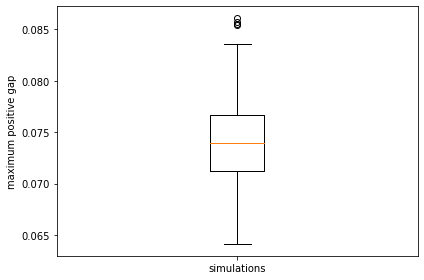

Median max gap: 0.07394694844544739


In [21]:
# ────── Example run & plot ──────
plt.figure(figsize=(6,4))
plt.boxplot(gaps, showfliers=True)
# plt.title(f"Max{{HD_k - HD_true}} per simulation  (k={params['k_dirs']})")
plt.ylabel("maximum positive gap")
plt.xticks([1], ["simulations"])
plt.tight_layout()
plt.show()

print("Median max gap:", np.median(gaps))


### Table 1 & 2

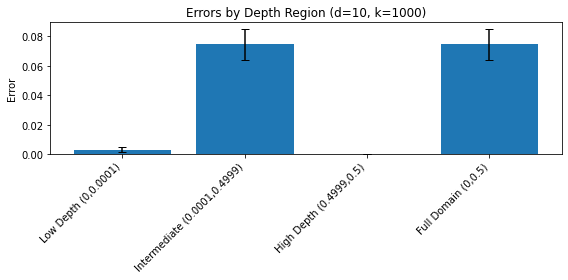

C:\Users\vital\AppData\Local\Temp\ipykernel_15728\1830760109.py:44: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  df_reg = df_reg.to_latex(index=False, float_format="%.3f")


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Предполагаем, что simulate_max_depth_gap и др. давно определены

# Настройки
N_iter, N_points, seed = 100, 500, 42

# 1) Таблица по глубинным регионам (d=10, k=1000)
d_fixed, k_fixed = 10, 1000
regions = {
    "Low Depth (0,0.0001)": (0.0, 0.4999),
    "Intermediate (0.0001,0.4999)": (0.0001, 0.0001),
    "High Depth (0.4999,0.5)"   : (0.4999, 0.0),
    "Full Domain (0,0.5)"       : (0.0, 0.0),
}

theoretical_bound = 0.12211

rows = []
for _, (name,(e1,e2)) in enumerate(regions.items()):
    gaps = simulate_max_depth_gap(N_iter, N_points, k_fixed, e1, e2, d_fixed, None, False, seed)
    rows.append([
        name,
        np.median(gaps),
        np.max(gaps),
        0.12211,
        100*(np.median(gaps)-0.12211)/0.12211
    ])
df_reg = pd.DataFrame(rows, columns=["Region","MedErr","SupErr","Theory","Diff%"])

# df_reg = df_reg.to_string(index=False)
# df_reg = df_reg.to_latex(index=False, float_format="%.3f")

plt.figure(figsize=(8,4))
plt.bar(df_reg["Region"], df_reg["MedErr"], yerr=df_reg["SupErr"]-df_reg["MedErr"], capsize=4)
plt.xticks(rotation=45, ha="right")
plt.title("Errors by Depth Region (d=10, k=1000)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# Saving
df_reg = df_reg.to_latex(index=False, float_format="%.3f")
with open("table_by_d.tex", "w") as f:
    f.write(df_reg)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # или from tqdm.notebook import tqdm

# Предполагаем, что simulate_max_depth_gap уже определена

# Настройки
N_iter, N_points, seed = 100, 500, 42
k_vary = 1000
ds = [2, 5, 10, 20]

# Здесь вы можете подставить свои теоретические границы для сравнения
# (должны быть той же длины, что и ds)
theoretical_bounds = [0.00014, 0.03997, 0.12211, 0.21854]

rows2 = []
for d in tqdm(ds, desc="Loop over dimensions"):
    # Полная область
    g_full = simulate_max_depth_gap(
        N_iter, N_points, k_vary,
        epsilon1=0.0, epsilon2=0.0,
        d=d, Sigma=None, reuse_points=False, seed=seed
    )
    # Intermediate
    g_int = simulate_max_depth_gap(
        N_iter, N_points, k_vary,
        epsilon1=0.0001, epsilon2=0.0001,
        d=d, Sigma=None, reuse_points=False, seed=seed
    )
    med_full = np.median(g_full)
    med_int  = np.median(g_int)
    theory = theoretical_bounds[ds.index(d)]
    rows2.append({
        "d": d,
        "FullMed":       med_full,
        "IntMed":        med_int,
        "Theory_Est":    theory,
        "DiffFull_%": 100*(med_full - theory)/theory if theory>0 else np.nan,
        "DiffInt_%":  100*(med_int  - theory)/theory if theory>0 else np.nan
    })

df_d = pd.DataFrame(rows2)

# Печать таблицы и сохранение в .tex
print(df_d.to_string(index=False))
with open("table_by_d.tex", "w", encoding="utf-8") as f:
    f.write(df_d.to_latex(index=False, float_format="%.3f",
        columns=["d","FullMed","IntMed","Theory_Est","DiffFull_%","DiffInt_%"],
        header=["$d$","Full Median","Int. Median","Theory","Δ Full (%)","Δ Int (%)"]))

Loop over dimensions: 100%|██████████████████████████████████████████████████████████████| 4/4 [00:27<00:00,  6.81s/it]

 d  FullMed   IntMed  Theory_Est  DiffFull_%  DiffInt_%
 2 0.000033 0.000033     0.00014  -76.135610 -76.128411
 5 0.021336 0.021338     0.03997  -46.618771 -46.614106
10 0.074495 0.074492     0.12211  -38.993395 -38.996005
20 0.139008 0.139008     0.21854  -36.392352 -36.392284



C:\Users\vital\AppData\Local\Temp\ipykernel_15728\2727493304.py:48: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df_d.to_latex(index=False, float_format="%.3f",


Loop over dimensions: 100%|██████████████████████████████████████████████████████████████| 3/3 [00:36<00:00, 12.03s/it]
C:\Users\vital\AppData\Local\Temp\ipykernel_15728\3474841223.py:53: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_k = df_k.to_latex(index=False, float_format="%.3f",


 k_dirs  Median_Error  Sup_Error  Theory_Error     Diff_%
    100      0.034296   0.065295       0.27027 -87.310423
   1000      0.003742   0.005311       0.12211 -96.935614
  10000      0.000833   0.001059       0.06500 -98.719049


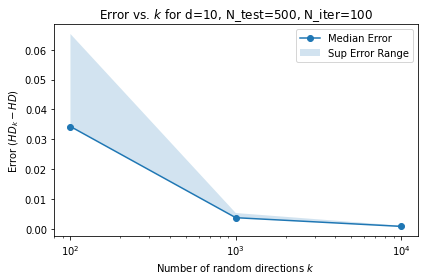

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Предполагается, что функция simulate_max_depth_gap уже определена
# Настройки
N_iter    = 100
N_points  = 500
d_fixed   = 10
eps_lo    = 0.0001
eps_hi    = 0.5-0.0001
seed      = 42

# Диапазон k_dirs для сравнения
ks = [100, 1000, 10000]

theoretical_bounds = [0.27027, 0.12211, 0.06500]


# Собираем результаты
records_k = []
for k in tqdm(ks, desc="Loop over dimensions"):
    gaps = simulate_max_depth_gap(
        N_iter=N_iter,
        N_points=N_points,
        k_dirs=k,
        epsilon1=eps_lo,
        epsilon2=eps_hi,
        d=d_fixed,
        Sigma=None,
        reuse_points=False,
        seed=seed
    )
    median_err = np.median(gaps)
    sup_err    = np.max(gaps)
    theory = theoretical_bounds[ks.index(k)]

    records_k.append({
        "k_dirs":       k,
        "Median_Error": median_err,
        "Sup_Error":    sup_err,
        "Theory_Error": theory,  # замените на ваши теоретические значения
        "Diff_%":       100*(median_err - theory)/theory
    })

# Формируем DataFrame
df_k = pd.DataFrame(records_k)

# Печать в консоль
print(df_k.to_string(index=False))

# Экспорт в LaTeX
latex_k = df_k.to_latex(index=False, float_format="%.3f",
    columns=["k_dirs","Median_Error","Theory_Error","Diff_%"],
    header=["$k$","Median Error","Theory Error","Diff (%)"])
with open("table_by_k.tex", "w", encoding="utf-8") as f:
    f.write(latex_k)

# График: Median Error vs k_dirs
plt.figure(figsize=(6,4))
plt.plot(df_k["k_dirs"], df_k["Median_Error"], marker='o', label="Median Error")
plt.fill_between(df_k["k_dirs"],
                 df_k["Median_Error"],
                 df_k["Sup_Error"],
                 alpha=0.2, label="Sup Error Range")
plt.xscale('log')
plt.xlabel("Number of random directions $k$")
plt.ylabel("Error ($HD_k - HD$)")
plt.title(f"Error vs. $k$ for d={d_fixed}, N_test={N_points}, N_iter={N_iter}")
plt.legend()
plt.tight_layout()
plt.show()


### High depth

In [240]:
# Example run & plot
params = dict(N_iter=100, 
              N_points=2000, 
              k_dirs=5000,
              epsilon1=0.0, 
              epsilon2=0.4, 
              d=5, 
              reuse_points=False)
max_gaps = simulate_max_depth_gap(**params)

plt.figure(figsize=(6,4))
plt.boxplot(max_gaps, showfliers=True)
plt.title(f"Max{{HD - HD_k}} per simulation (k={params['k_dirs']})")
plt.ylabel("maximum positive gap")
plt.xticks([1], ["simulations"])
plt.tight_layout()

print("Median max gap:", np.median(max_gaps))

KeyboardInterrupt: 

### Intermediate depth

In [ ]:
# Example run & plot
params = dict(N_iter=100, 
              N_points=2000, 
              k_dirs=5000,
              epsilon1=0.05, 
              epsilon2=0.1, 
              d=5, 
              reuse_points=False)
max_gaps = simulate_max_depth_gap(**params)

plt.figure(figsize=(6,4))
plt.boxplot(max_gaps, showfliers=True)
plt.title(f"Max{{HD - HD_k}} per simulation (k={params['k_dirs']})")
plt.ylabel("maximum positive gap")
plt.xticks([1], ["simulations"])
plt.tight_layout()

print("Median max gap:", np.median(max_gaps))

### Low depth

In [ ]:
# Example run & plot
params = dict(N_iter=100, 
              N_points=2000, 
              k_dirs=5000,
              epsilon1=0.0, 
              epsilon2=0.45, 
              d=5, 
              reuse_points=False)
max_gaps = simulate_max_depth_gap(**params)

plt.figure(figsize=(6,4))
plt.boxplot(max_gaps, showfliers=True)
plt.title(f"Max{{HD - HD_k}} per simulation (k={params['k_dirs']})")
plt.ylabel("maximum positive gap")
plt.xticks([1], ["simulations"])
plt.tight_layout()

print("Median max gap:", np.median(max_gaps))